In [1]:
import pandas as pd
import matplotlib.pyplot as plt
data_rbc_1 = pd.read_csv("/workspaces/CUBES/exp/hannes/Leiden-study/03_evaluate_controlled/Eplus-env-evaluate_RBC_eco_case_10_year_2022_rep_0_tset_20.0_tsb_17.0-v1-res2/Eplus-env-sub_run1/output/eplusout.csv")
data_sac = pd.read_csv("/workspaces/CUBES/agent_results_case10.txt")
#data_aggressive = pd.read_csv("/workspaces/elizabeth-homes/exp/hannes/Leiden-study/03_evaluate_controlled/Eplus-env-evaluate_RBC_aggressive_case_0_year_2022_rep_0-v1-res3/Eplus-env-sub_run1/output/eplusout.csv")
#data_sac = pd.read_csv("/workspaces/elizabeth-homes/exp/hannes/Leiden-study/03_evaluate_controlled/eplusout_vague_mountain.csv")

<jemalloc>: MADV_DONTNEED does not work (memset will be used instead)
<jemalloc>: (This is the expected behaviour if you are running under QEMU)


In [2]:
data_sac.columns

Index(['Date/Time',
       'Environment:Site Outdoor Air Drybulb Temperature [C](TimeStep)',
       'BEDROOM:Zone People Occupant Count [](TimeStep)',
       'LIVING:Zone People Occupant Count [](TimeStep)',
       'BEDROOM:Zone Operative Temperature [C](TimeStep)',
       'LIVING:Zone Operative Temperature [C](TimeStep)',
       'SUBFLOOR:Zone Operative Temperature [C](TimeStep)',
       'BEDROOM:Zone Ventilation Air Change Rate [ach](TimeStep)',
       'LIVING:Zone Ventilation Air Change Rate [ach](TimeStep)',
       'BEDROOM:Zone Thermostat Operative Temperature [C](TimeStep)',
       'LIVING:Zone Thermostat Operative Temperature [C](TimeStep)',
       'BEDROOM:Zone Air CO2 Concentration [ppm](TimeStep)',
       'LIVING:Zone Air CO2 Concentration [ppm](TimeStep)',
       'SUBFLOOR:Zone Air CO2 Concentration [ppm](TimeStep)',
       'SYNERION 24M:Electric Storage Battery Charge State [Ah](TimeStep)',
       'SYNERION 24M:Electric Storage Charge Power [W](TimeStep)',
       'SYNERION 

In [19]:
# def func(row):
#     if row['LIVING:Zone People Occupant Count [](TimeStep)'] > 0:
#         return 1
#     else:
#         return 0

#data_rbc_1['LIVING:Occupied'] = 0
#idx = data_rbc_1.loc[:,'LIVING:Zone People Occupant Count [](TimeStep)'] > 0
#data_rbc_1[idx,'LIVING:Occupied'] = 1
#data_rbc_1['LIVING:Zone People Occupant Count [](TimeStep)'].clip(upper=1)
test = (data_rbc_1['LIVING:Zone Operative Temperature [C](TimeStep)'].clip(lower=20) - data_rbc_1['Environment:Site Outdoor Air Drybulb Temperature [C](TimeStep)']).clip(lower=0) * data_rbc_1['LIVING:Zone People Occupant Count [](TimeStep)'].clip(upper=1)

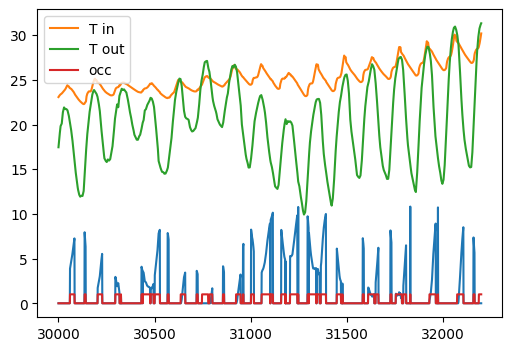

In [30]:
t_start = 30000
t_end = 32200
fig,ax = plt.subplots(figsize=(6,4))
ax.plot(test[t_start:t_end])
ax.plot(data_rbc_1['LIVING:Zone Operative Temperature [C](TimeStep)'][t_start:t_end],label="T in")
ax.plot(data_rbc_1['Environment:Site Outdoor Air Drybulb Temperature [C](TimeStep)'][t_start:t_end],label="T out")
ax.plot(data_rbc_1['LIVING:Zone People Occupant Count [](TimeStep)'].clip(upper=1)[t_start:t_end],label="occ")
ax.legend()

Text(0.5, 0, 'timestep')

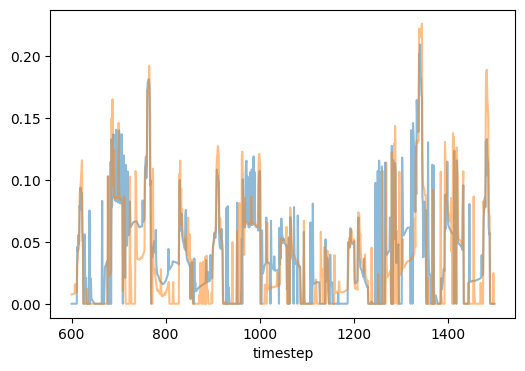

In [4]:
t_start = 600
t_end = 1500
fig,ax = plt.subplots(figsize=(6,4))
ax.plot(data_rbc_1['Site:Environmental Impact Total CO2 Emissions Carbon Equivalent Mass [kg](TimeStep) '][t_start:t_end],alpha=0.5)
ax.plot(data_sac['Site:Environmental Impact Total CO2 Emissions Carbon Equivalent Mass [kg](TimeStep) '][t_start:t_end],alpha=0.5)
#ax.set_ylabel("Cumulative emissions [kg CO2e]")
ax.set_xlabel("timestep")



Text(0, 0.5, 'Battery Charge State [Ah]')

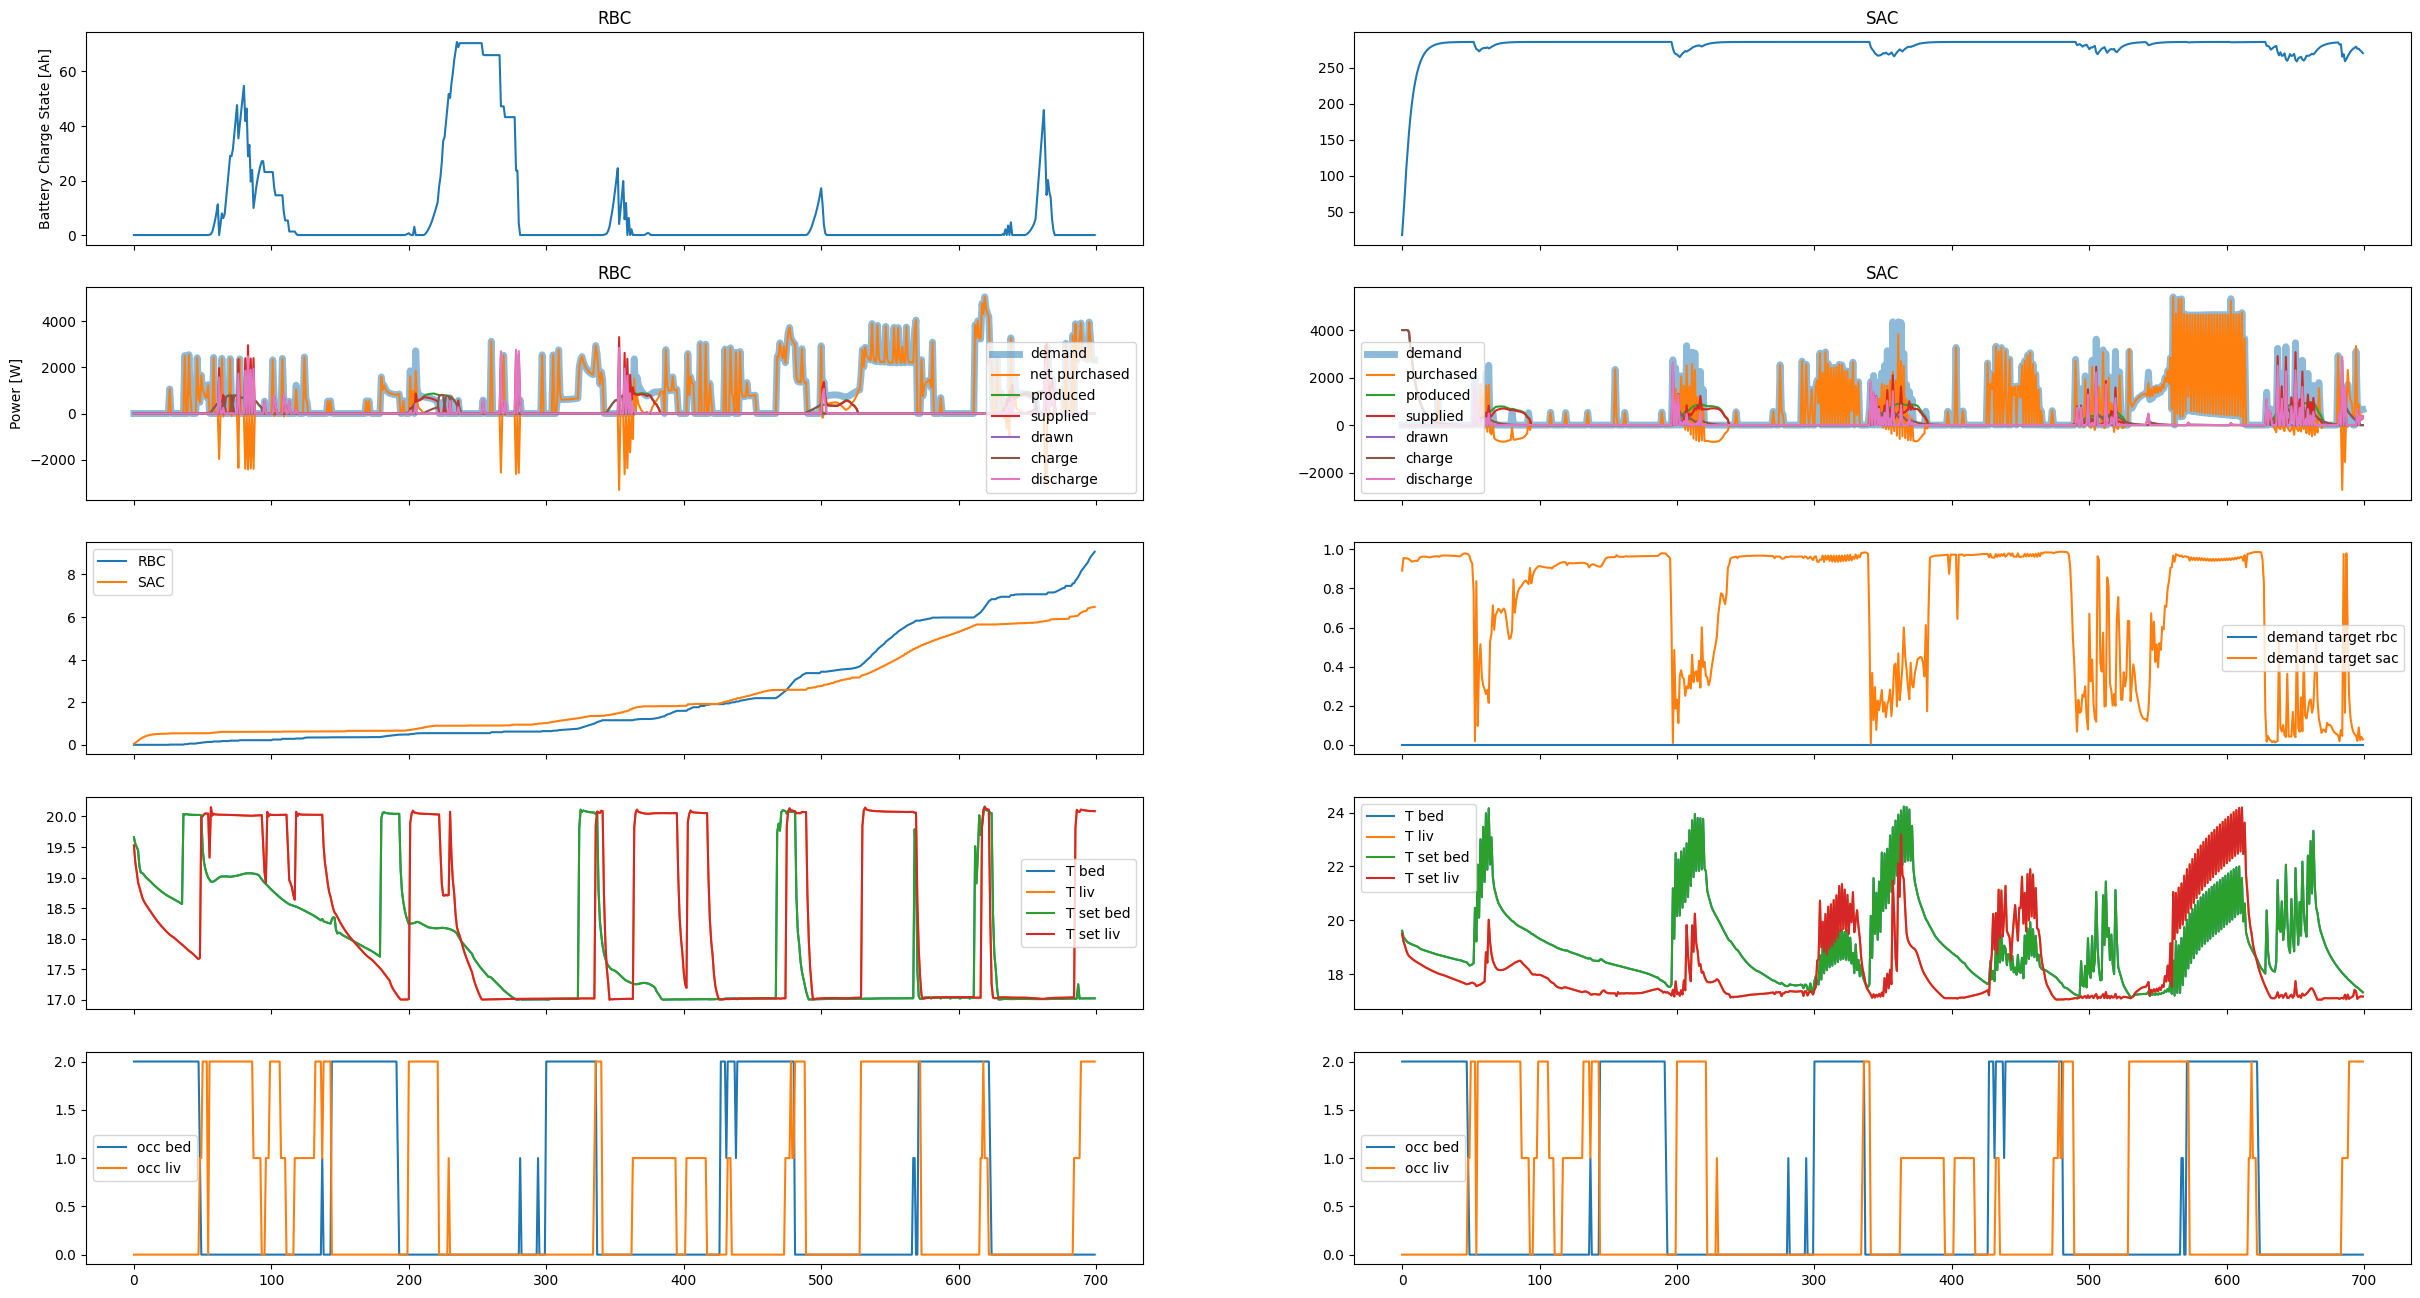

In [12]:
import numpy as np
t_start = 000
t_end = 700
fig,ax = plt.subplots(figsize=(30,16),nrows=5,ncols=2,sharex=True)

#ax.plot(np.arange(0,24,1/6),data_trivial['LIVING:Zone Thermostat Heating Setpoint Temperature [C](TimeStep)'][t_start:t_end],label="Tset tr")
ax[4,0].plot(data_rbc_1['BEDROOM:Zone People Occupant Count [](TimeStep)'][t_start:t_end],label="occ bed")
ax[4,0].plot(data_rbc_1['LIVING:Zone People Occupant Count [](TimeStep)'][t_start:t_end],label="occ liv")
ax[4,1].plot(data_sac['BEDROOM:Zone People Occupant Count [](TimeStep)'][t_start:t_end],label="occ bed")
ax[4,1].plot(data_sac['LIVING:Zone People Occupant Count [](TimeStep)'][t_start:t_end],label="occ liv")
ax[3,0].plot(data_rbc_1['BEDROOM:Zone Operative Temperature [C](TimeStep)'][t_start:t_end],label="T bed")
ax[3,0].plot(data_rbc_1['LIVING:Zone Operative Temperature [C](TimeStep)'][t_start:t_end],label="T liv")
ax[3,0].plot(data_rbc_1['BEDROOM:Zone Thermostat Operative Temperature [C](TimeStep)'][t_start:t_end],label="T set bed")
ax[3,0].plot(data_rbc_1['LIVING:Zone Thermostat Operative Temperature [C](TimeStep)'][t_start:t_end],label="T set liv")
ax[3,1].plot(data_sac['BEDROOM:Zone Operative Temperature [C](TimeStep)'][t_start:t_end],label="T bed")
ax[3,1].plot(data_sac['LIVING:Zone Operative Temperature [C](TimeStep)'][t_start:t_end],label="T liv")
ax[3,1].plot(data_sac['BEDROOM:Zone Thermostat Operative Temperature [C](TimeStep)'][t_start:t_end],label="T set bed")
ax[3,1].plot(data_sac['LIVING:Zone Thermostat Operative Temperature [C](TimeStep)'][t_start:t_end],label="T set liv")
ax[0,0].plot(data_rbc_1['SYNERION 24M:Electric Storage Battery Charge State [Ah](TimeStep)'][t_start:t_end],label="charge state")
ax[0,1].plot(data_sac['SYNERION 24M:Electric Storage Battery Charge State [Ah](TimeStep)'][t_start:t_end],label="charge state")

ax[1,0].plot(data_rbc_1['Whole Building:Facility Total Electricity Demand Rate [W](TimeStep)'][t_start:t_end],label="demand",linewidth=5,alpha=0.5)
ax[1,1].plot(data_sac['Whole Building:Facility Total Electricity Demand Rate [W](TimeStep)'][t_start:t_end],label="demand",linewidth=5,alpha=0.5)
#ax[1,0].plot(data_rbc_1['Whole Building:Facility Total Produced Electricity Rate [W](TimeStep)'][t_start:t_end],label="produced rbc")
#ax[1,1].plot(data_rbc_2['Whole Building:Facility Total Produced Electricity Rate [W](TimeStep)'][t_start:t_end],label="produced epl")
ax[1,0].plot(data_rbc_1['Whole Building:Facility Net Purchased Electricity Rate [W](TimeStep)'][t_start:t_end],label="net purchased")
ax[1,1].plot(data_sac['Whole Building:Facility Net Purchased Electricity Rate [W](TimeStep)'][t_start:t_end],label="purchased")
ax[1,0].plot(data_rbc_1['DC WITH INVERTER AND SYNERION 24M:Electric Load Center Produced Electricity Rate [W](TimeStep)'][t_start:t_end],label="produced")
ax[1,0].plot(data_rbc_1['DC WITH INVERTER AND SYNERION 24M:Electric Load Center Supplied Electricity Rate [W](TimeStep)'][t_start:t_end],label="supplied")
ax[1,0].plot(data_rbc_1['DC WITH INVERTER AND SYNERION 24M:Electric Load Center Drawn Electricity Rate [W](TimeStep)'][t_start:t_end],label="drawn")
#ax[1,0].plot(data_rbc_1['DC WITH INVERTER AND SYNERION 24M:Electric Load Center Requested Electricity Rate [W](TimeStep)'][t_start:t_end],label="requested")

ax[1,1].plot(data_sac['DC WITH INVERTER AND SYNERION 24M:Electric Load Center Produced Electricity Rate [W](TimeStep)'][t_start:t_end],label="produced")
ax[1,1].plot(data_sac['DC WITH INVERTER AND SYNERION 24M:Electric Load Center Supplied Electricity Rate [W](TimeStep)'][t_start:t_end],label="supplied")
ax[1,1].plot(data_sac['DC WITH INVERTER AND SYNERION 24M:Electric Load Center Drawn Electricity Rate [W](TimeStep)'][t_start:t_end],label="drawn")
#ax[1,1].plot(data_sac['DC WITH INVERTER AND SYNERION 24M:Electric Load Center Requested Electricity Rate [W](TimeStep)'][t_start:t_end],label="requested")
#ax[1,0].plot(data_rbc_1['Whole Building:Facility Total Purchased Electricity Rate [W](TimeStep)'][t_start:t_end],label="total purchased rbc")
#ax[1,0].plot(data_rbc_1['Whole Building:Facility Total Surplus Electricity Rate [W](TimeStep)'][t_start:t_end],label="total surplus rbc")
#ax[1,0].set_ylim([-1,1])
ax[1,0].plot(data_rbc_1['SYNERION 24M:Electric Storage Charge Power [W](TimeStep)'][t_start:t_end],label="charge")
ax[1,1].plot(data_sac['SYNERION 24M:Electric Storage Charge Power [W](TimeStep)'][t_start:t_end],label="charge")
ax[1,0].plot(data_rbc_1['SYNERION 24M:Electric Storage Discharge Power [W](TimeStep)'][t_start:t_end],label="discharge")#
ax[1,1].plot(data_sac['SYNERION 24M:Electric Storage Discharge Power [W](TimeStep)'][t_start:t_end],label="discharge")
# ax.plot(data_rbc_2['BEDROOM:Zone Air Temperature [C](TimeStep)'][t_start:t_end],label="T bed 2")
# ax.plot(data_rbc_2['LIVING:Zone Air Temperature [C](TimeStep)'][t_start:t_end],label="T liv 2")
# ax.plot(data_rbc_2['SYNERION 24M:Electric Storage Battery Charge State [Ah](TimeStep)'][t_start:t_end],label="charge state 2")
ax[2,0].plot(data_rbc_1['Site:Environmental Impact Total CO2 Emissions Carbon Equivalent Mass [kg](TimeStep) '][t_start:t_end].cumsum(),label="RBC")
ax[2,0].plot(data_sac['Site:Environmental Impact Total CO2 Emissions Carbon Equivalent Mass [kg](TimeStep) '][t_start:t_end].cumsum(),label="SAC")

ax[2,1].plot(data_rbc_1['UTILITY DEMAND TARGET SCHEDULE-EXT:Schedule Value [](TimeStep)'][t_start:t_end],label="demand target rbc")
ax[2,1].plot(data_sac['UTILITY DEMAND TARGET SCHEDULE-EXT:Schedule Value [](TimeStep)'][t_start:t_end],label="demand target sac")

#ax[2,1].plot(data_rbc_2['Whole Building:Facility Net Purchased Electricity Rate [W](TimeStep)'][t_start:t_end].cumsum(),label="purchased epl")
#ax.plot(data_trivial['Whole Building:Facility Total Produced Electricity Rate [W](TimeStep)'][t_start:t_end],label="E prod")
#ax.plot(data_trivial['Environment:Site Outdoor Air Drybulb Temperature [C](TimeStep)'][t_start:t_end],label="Tout")
#ax.plot(data_trivial['1 HOUR TEMPERATURE FORECAST SCHEDULE:Schedule Value [](TimeStep)'][t_start:t_end],label="Tout forecast 1")
#ax.plot(data_trivial['2 HOUR TEMPERATURE FORECAST SCHEDULE:Schedule Value [](TimeStep)'][t_start:t_end],label="Tout forecast 2")
#ax.plot(data_trivial['4 HOUR TEMPERATURE FORECAST SCHEDULE:Schedule Value [](TimeStep)'][t_start:t_end],label="Tout forecast 4")

#ax.plot(data_rbc_1['LIVING:Zone Thermostat Operative Temperature [C](TimeStep)'][t_start:t_end],label="T set liv")
#ax.plot(data_rbc_1['BEDROOM:Zone Thermostat Heating Setpoint Temperature [C](TimeStep)'][t_start:t_end],label="T ")

#ax.plot(data_trivial['Environment:Site Outdoor Air Relative Humidity [%](TimeStep)'][t_start:t_end],label="ach bed")
#ax.plot((data_trivial['BEDROOM:Zone Air CO2 Concentration [ppm](TimeStep)'][t_start:t_end])/100,label="CO2 bed")

#ax.plot(data_sac['LIVING:Zone Thermostat Heating Setpoint Temperature [C](TimeStep)'][t_start:t_end],label="Tset sac")
#ax.plot(data_sac['LIVING:Zone Air Temperature [C](TimeStep)'][t_start:t_end],label="T SAC")
#plt.plot(data_aggressive['LIVING:Zone Thermostat Heating Setpoint Temperature [C](TimeStep)'][t_start:t_end],label="Tlset ag")
#plt.plot(data_aggressive['LIVING:Zone Air Temperature [C](TimeStep)'][t_start:t_end],label="Tl ag")
ax[0,0].set_title("RBC")
ax[1,0].set_title("RBC")
ax[0,1].set_title("SAC")
ax[1,1].set_title("SAC")
ax[1,0].legend()
ax[1,1].legend()
ax[2,0].legend()
ax[2,1].legend()
ax[3,0].legend()
ax[3,1].legend()
ax[4,0].legend()
ax[4,1].legend()
#ax.set_xlim([15,24])
ax[1,0].set_ylabel("Power [W]")
ax[0,0].set_ylabel("Battery Charge State [Ah]")

#ax.set_xlabel("hour")
# fig.tight_layout()
# fig.savefig("thermostat_example.pdf")

NameError: name 'data_trivial' is not defined

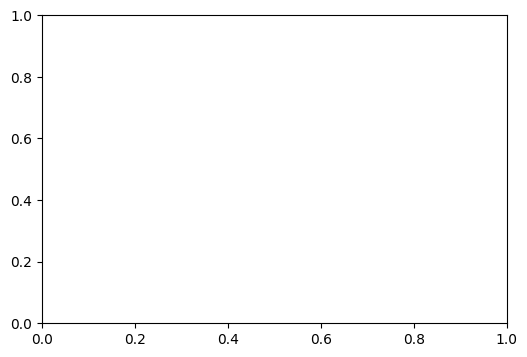

In [93]:
t_start = 0
t_end = 2000
fig,ax = plt.subplots(figsize=(6,4))
ax.plot(data_trivial['Environment:Site Outdoor Air Drybulb Temperature [C](TimeStep)'][t_start:t_end],label="Tout")
ax.plot(data_trivial['1 HOUR TEMPERATURE FORECAST SCHEDULE:Schedule Value [](TimeStep)'][t_start:t_end],label="Tout forecast 1")
ax.plot(data_trivial['2 HOUR TEMPERATURE FORECAST SCHEDULE:Schedule Value [](TimeStep)'][t_start:t_end],label="Tout forecast 2")
ax.plot(data_trivial['4 HOUR TEMPERATURE FORECAST SCHEDULE:Schedule Value [](TimeStep)'][t_start:t_end],label="Tout forecast 4")
ax.plot(data_trivial['12 HOUR TEMPERATURE FORECAST SCHEDULE:Schedule Value [](TimeStep)'][t_start:t_end],label="Tout forecast 12")
ax.set_ylim([0,20])

plt.legend()
#ax.plot(data_trivial['Site:Environmental Impact Total CO2 Emissions Carbon Equivalent Mass [kg](TimeStep) '][t_start:t_end]*1000/(data_trivial['Whole Building:Facility Total Electricity Demand Rate [W](TimeStep)'][t_start:t_end]/1000/6))


In [ ]:
ax.plot(data_trivial['Whole Building:Facility Total Electricity Demand Rate [W](TimeStep)'][t_start:t_end])

NameError: name 'data_trivial' is not defined

In [ ]:
data_trivial['Whole Building:Facility Total Electricity Demand Rate [W](TimeStep)'][t_start:t_end]

0          0.000000
1          0.000000
2       2377.749769
3          0.000000
4       2224.173664
           ...     
1995     200.000000
1996     200.000000
1997    3001.454051
1998    3865.161360
1999    4486.431330
Name: Whole Building:Facility Total Electricity Demand Rate [W](TimeStep), Length: 2000, dtype: float64

In [ ]:
data_trivial['Environment:Site Outdoor Air Drybulb Temperature [C](TimeStep)'].min()

-6.55

In [ ]:
data_trivial['Site:Environmental Impact Total CO2 Emissions Carbon Equivalent Mass [kg](TimeStep) '].sum()

852.4952965839942

NameError: name 'data_aggressive' is not defined

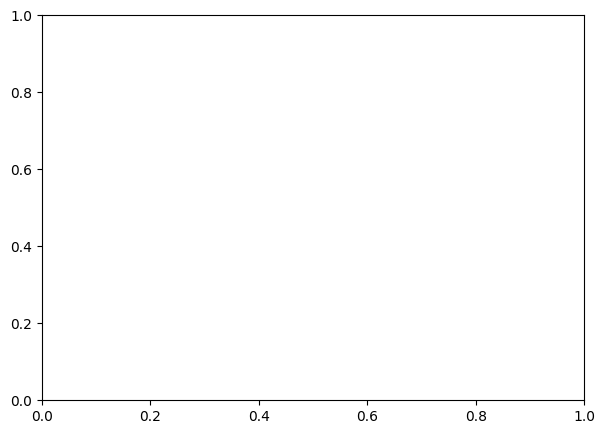

In [ ]:
fig, ax = plt.subplots(figsize=(7,5))

controllers = ['no controller', 'aggressive controller', 'SAC']
emissions = [data_trivial['Site:Environmental Impact Total CO2 Emissions Carbon Equivalent Mass [kg](TimeStep) '].sum(),
             data_aggressive['Site:Environmental Impact Total CO2 Emissions Carbon Equivalent Mass [kg](TimeStep) '].sum(),
             data_sac['Site:Environmental Impact Total CO2 Emissions Carbon Equivalent Mass [kg](TimeStep) '].sum()]
#bar_labels = ['red', 'blue', '_red']
bar_colors = ['tab:blue', 'tab:orange','tab:green']

ax.bar(controllers, emissions, color=bar_colors)
ax.set_ylabel("Annual CO2e emissions [kg]")
fig.savefig("case0_barchart_emissions.pdf")

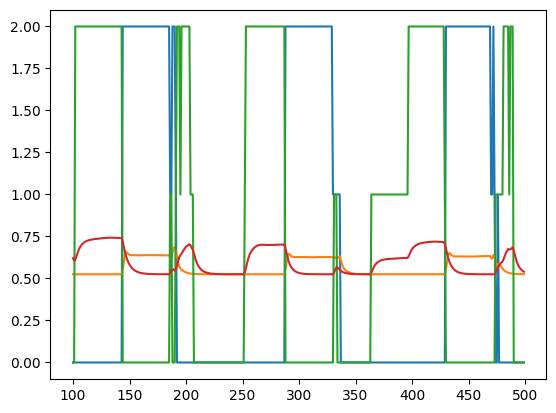

In [ ]:
t_start = 100
t_end = 500
plt.plot(data_trivial['BEDROOM:Zone People Occupant Count [](TimeStep)'][t_start:t_end])
plt.plot(data_trivial['BEDROOM:Zone Air CO2 Concentration [ppm](TimeStep)'][t_start:t_end]/800)
plt.plot(data_trivial['LIVING:Zone People Occupant Count [](TimeStep)'][t_start:t_end])
plt.plot(data_trivial['LIVING:Zone Air CO2 Concentration [ppm](TimeStep)'][t_start:t_end]/800)